In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Clases de CIFAR-10
clases = ['airplane', 'automobile', 'bird', 'cat', 'deer',
          'dog', 'frog', 'horse', 'ship', 'truck']

# Descargar y cargar dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=True,
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False,
    download=True, 
    transform=transform
)

print(f"Imágenes de entrenamiento: {len(train_dataset):,}")
print(f"Imágenes de prueba: {len(test_dataset):,}")
print(f"Clases: {clases}")

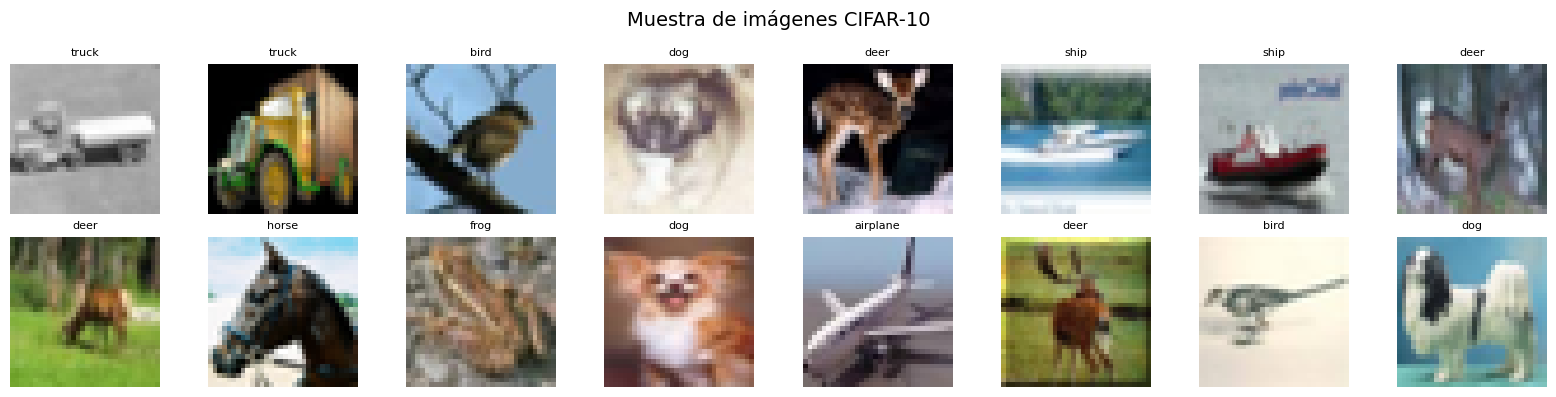


Tamaño de cada imagen: torch.Size([3, 32, 32])
Tipo de datos: torch.float32


In [7]:

import os

# Visualizar imágenes del dataset
dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
imagenes, etiquetas = next(iter(dataloader))

def desnormalizar(img):
    img = img * 0.5 + 0.5
    return img

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = desnormalizar(imagenes[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(clases[etiquetas[i]], fontsize=8)
    ax.axis('off')

plt.suptitle("Muestra de imágenes CIFAR-10", fontsize=14)
plt.tight_layout()
os.makedirs("../data", exist_ok=True)
plt.savefig("../data/cifar10_muestra.png", dpi=150)
plt.show()

print(f"\nTamaño de cada imagen: {imagenes[0].shape}")
print(f"Tipo de datos: {imagenes[0].dtype}")

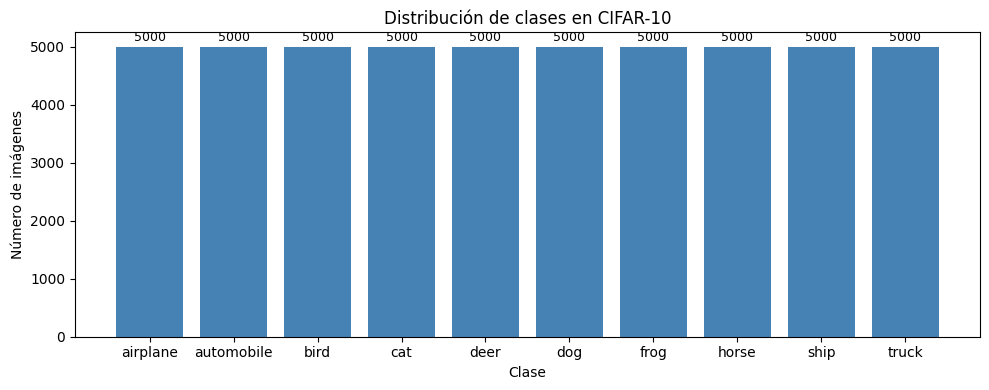


Clase con más imágenes: airplane (5,000)
Clase con menos imágenes: airplane (5,000)
Dataset balanceado: True


In [8]:
# Distribución de clases
conteo = [0] * 10
for _, etiqueta in train_dataset:
    conteo[etiqueta] += 1

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(clases, conteo, color='steelblue')
ax.set_title("Distribución de clases en CIFAR-10")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de imágenes")

for bar, count in zip(bars, conteo):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("../data/distribucion_clases.png", dpi=150)
plt.show()

print(f"\nClase con más imágenes: {clases[conteo.index(max(conteo))]} ({max(conteo):,})")
print(f"Clase con menos imágenes: {clases[conteo.index(min(conteo))]} ({min(conteo):,})")
print(f"Dataset balanceado: {len(set(conteo)) == 1}")